# California House Price Prediction

This project builds a regression model to predict median house prices in California using the classic **California Housing dataset**. The workflow covers data cleaning, exploratory data analysis, outlier handling, feature engineering, and comparison of four regression models (Linear Regression, Ridge, Lasso, and Random Forest).

**Dataset:** California Housing dataset (20,640 rows, 10 columns)  
**Target variable:** `median_house_value`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 3. Exploratory Data Analysis

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [8]:
df.shape

(20640, 10)

### Correlation Heatmap
Checking how numeric features correlate with each other and with the target variable.

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - California Housing")
plt.show()

## 4. Handle Missing Values

In [9]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df["total_bedrooms"]=df["total_bedrooms"].fillna(df["total_bedrooms"].median())


In [11]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 5. Encode Categorical Variables

In [16]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [17]:
df=pd.get_dummies(df,columns=["ocean_proximity"],drop_first=True)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [19]:
df = df.astype({col: int for col in df.select_dtypes(bool).columns})
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


## 6. Feature Engineering
Creating new features that may carry more predictive signal than the raw columns alone:
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

In [21]:
df["rooms_per_household"]=df["total_rooms"] / df["households"]
df["bedrooms_per_room"]=df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"]=df["population"] / df["households"]
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0,6.281853,0.172096,2.181467


In [22]:
df.shape

(20640, 16)

## 7. Outlier Detection and Handling
Outliers in `median_house_value` are detected using the IQR method and **capped** (not removed) to preserve dataset size while limiting the influence of extreme values.

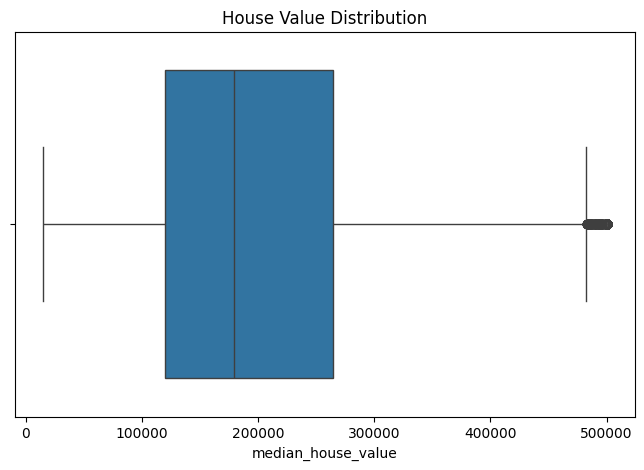

Outliers found: 1071
Upper bound: 482412.5


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot dekho
plt.figure(figsize=(8,5))
sns.boxplot(x=df["median_house_value"])
plt.title("House Value Distribution")
plt.show()

# IQR method
Q1 = df["median_house_value"].quantile(0.25)
Q3 = df["median_house_value"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["median_house_value"] < lower) | (df["median_house_value"] > upper)]
print(f"Outliers found: {len(outliers)}")
print(f"Upper bound: {upper}")

In [25]:
# Cap karo — delete nahi, boundary pe limit karo
df["median_house_value"] = df["median_house_value"].clip(lower=lower, upper=upper)

# Verify karo
print("Max value after capping:", df["median_house_value"].max())
print("Shape:", df.shape)

Max value after capping: 482412.5
Shape: (20640, 16)


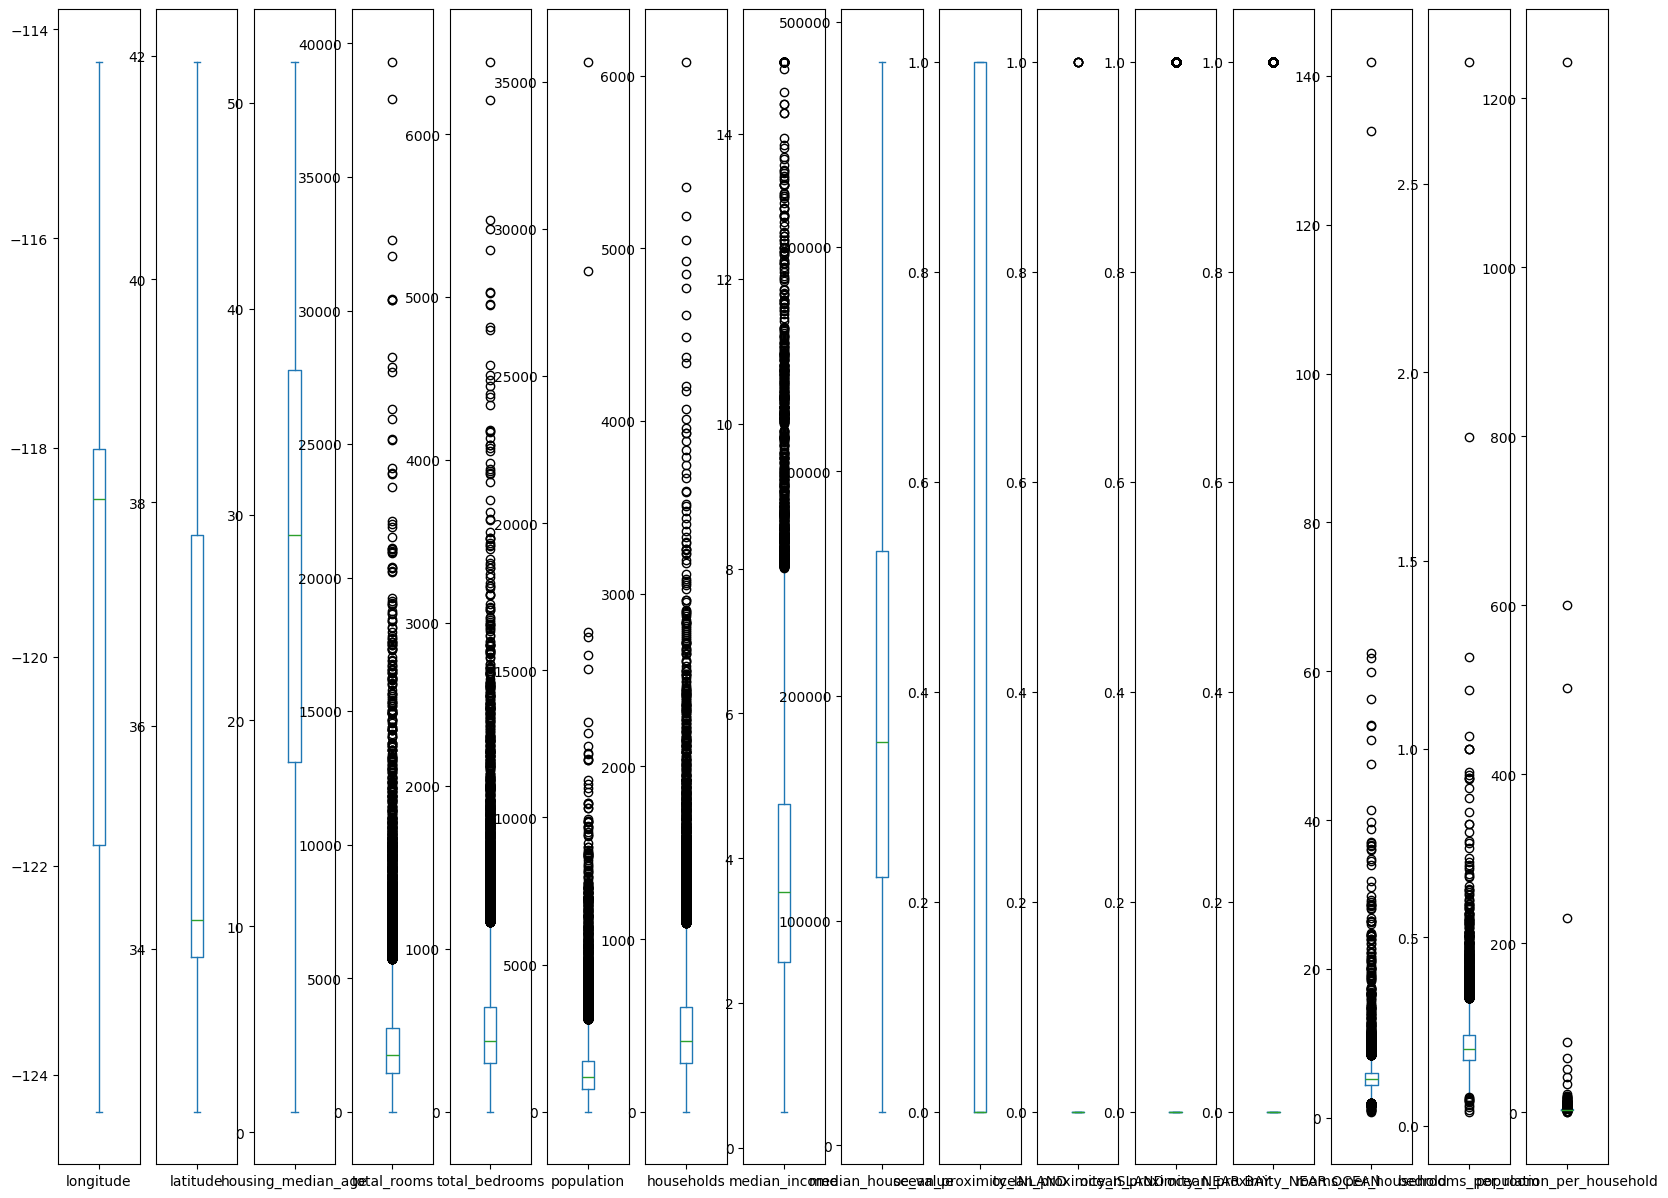

In [ ]:
df.plot(kind='box', subplots=True, figsize=(20,15))
plt.show()

## 8. Train-Test Split and Feature Scaling

In [ ]:
# Select feature and target
X=df.drop("median_house_value",axis=1)
y=df["median_house_value"]

In [31]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## 9. Model Training and Evaluation
Four regression models are trained and compared using MAE, RMSE, and R² score.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
# Model selection
model=LinearRegression()
# Model train
model.fit(X_train_scaled,y_train)
# Model predict
y_pred=model.predict(X_test_scaled)
# Evaluate
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"MAE:{mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2:{r2:.2f}")

MAE:50199.02
RMSE:71122.48
R2:0.60


In [38]:
from sklearn.linear_model import Ridge
model=Ridge(alpha=1.0)
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"MAE:{mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2:{r2:.2f}")

MAE:50198.68
RMSE:71120.34
R2:0.60


In [40]:
from sklearn.linear_model import Lasso
model=Lasso(alpha=100)
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"MAE:{mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2:{r2:.2f}")

MAE:50144.55
RMSE:70978.75
R2:0.60


In [41]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"MAE:{mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2:{r2:.2f}")

MAE:31859.69
RMSE:49233.68
R2:0.81


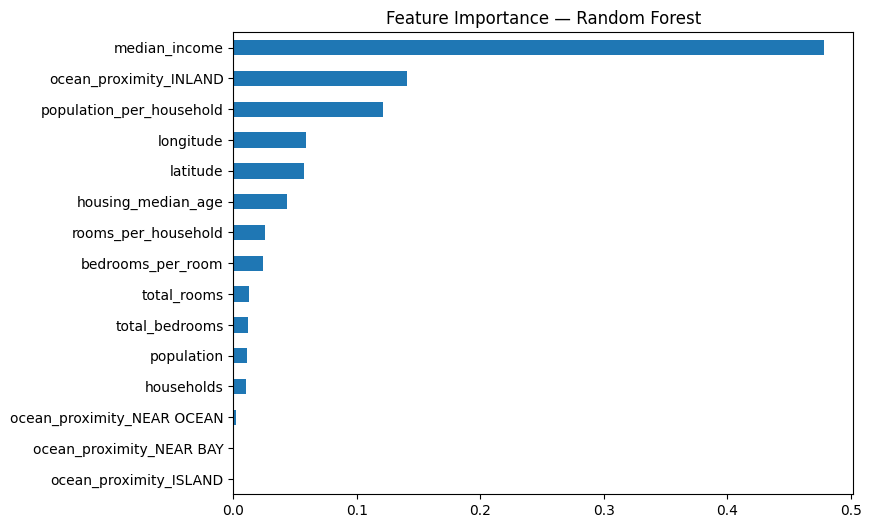

In [42]:
feat_imp=pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance — Random Forest")
plt.show()

In [ ]:
results={
    "Model": ["Linear Regression", "Ridge", "Lasso", "Random Forest"],
    "MAE": [50199, 50198, 50144, 31859],
    "RMSE": [71122, 71120, 70978, 49233],
    "R²": [0.60, 0.60, 0.60, 0.81]
}

results_df=pd.DataFrame(results)
print(results_df)

               Model    MAE   RMSE    R²
0  Linear Regression  50199  71122  0.60
1              Ridge  50198  71120  0.60
2              Lasso  50144  70978  0.60
3      Random Forest  31859  49233  0.81


## 10. Sample Prediction

In [ ]:
new_house=pd.DataFrame({
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [41.0],
    'total_rooms': [880.0],
    'total_bedrooms': [129.0],
    'population': [322.0],
    'households': [126.0],
    'median_income': [8.3252],
    'ocean_proximity_INLAND': [0],
    'ocean_proximity_ISLAND': [0],      # yeh add kiya
    'ocean_proximity_NEAR BAY': [1],    # NEAR BAY select kiya
    'ocean_proximity_NEAR OCEAN': [0],
    'rooms_per_household': [880/126],
    'bedrooms_per_room': [129/880],
    'population_per_household': [322/126]
})
new_house_scaled=scaler.transform(new_house)
price=model.predict(new_house_scaled)
print(f"Predicted House Price: ${price[0]:,.2f}")

Predicted House Price: $405,701.25


In [ ]:
print("HOUSE PRICE PREDICTOR")
longitude=float(input("Longitude: "))
latitude=float(input("Latitude: "))
age=float(input("Housing Age: "))
total_rooms=float(input("Total Rooms: "))
total_bedrooms=float(input("Total Bedrooms: "))
population=float(input("Population: "))
households=float(input("Households: "))
income=float(input("Median Income: "))
# Feature engineering
rooms_per_household=total_rooms/households
bedrooms_per_room=total_bedrooms/total_rooms
population_per_household=population/households
# Ocean proximity
print("\nOcean Proximity:")
print("1. INLAND")
print("2. ISLAND")
print("3. NEAR BAY")
print("4. NEAR OCEAN")
choice=input("Choose (1-4): ")
op_inland=op_island = op_near_bay = op_near_ocean = 0
if choice=="1": op_inland=1
elif choice=="2": op_island=1
elif choice=="3": op_near_bay=1
elif choice=="4": op_near_ocean=1
new_house=pd.DataFrame([[
    longitude, latitude, age, total_rooms, total_bedrooms,
    population, households, income,
    op_inland, op_island, op_near_bay, op_near_ocean,
    rooms_per_household, bedrooms_per_room, population_per_household
]], columns=X.columns)
# Scale + Predict
new_house_scaled=scaler.transform(new_house)
price = model.predict(new_house_scaled)
print(f"\n Predicted House Price: ${price[0]:,.2f}")

=== House Price Predictor ===

Ocean Proximity:
1. INLAND
2. ISLAND
3. NEAR BAY
4. NEAR OCEAN

🏠 Predicted House Price: $391,804.25


## 11. Conclusion

Four regression models were trained and compared on the California Housing dataset:

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 50,199 | 71,122 | 0.60 |
| Ridge | 50,198 | 71,120 | 0.60 |
| Lasso | 50,144 | 70,978 | 0.60 |
| **Random Forest** | **31,859** | **49,233** | **0.81** |

**Random Forest performed best**, improving R² from 0.60 to 0.81 and reducing MAE by roughly 37% compared to the linear models. This is expected since Random Forest can capture non-linear relationships between location, income, and housing age that linear models cannot.

**Limitations and future improvements:**
- Hyperparameters for Random Forest were left at default values; tuning with GridSearchCV could improve results further.
- Geographic features (`longitude`, `latitude`) were used as raw numbers rather than being clustered or binned by region, which could capture location effects better.
- No cross-validation was performed; results are based on a single train-test split.